# Análise exploratória dos dados
_EDA - Exploratory Data Analysis_

---

## Sumário

1. **Importação de bibliotecas**
2. **Carregamento da base**
3. **Análise do dataframe**
   - 3.1. Volumetria
   - 3.2. Tipagem, Nulos e Cardinalidade
   - 3.3. Duplicidade
   - 3.4. Medidas Estatísticas
   - 3.5. Boxplot e Outliers das Variáveis Numéricas
   - 3.6. Distribuição das Variáveis Numéricas
   - 3.7. Análise da Distribuição das Variáveis Numéricas
4. **Análise exploratória dos dados**

5. **Insights e recomendações**

<br>

---

<br>

## 1. Importação de bibliotecas

In [21]:
# Importação de bibliotecas e definições de parâmetros

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats

In [22]:
# Configurações para exibição de dados no Jupyter Notebook

# Configurar opção para exibir todas as linhas do Dataframe
pd.set_option('display.max_rows', None)

# Configurar para exibir o conteúdo completo das colunas
pd.set_option('display.max_colwidth', None)

# Configurar a supressão de mensagens de aviso durante a execução
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos do seaborn
sns.set_style('whitegrid')

## 2. Carregamento da base

In [23]:
# Criando um dataframe a partir do arquivo CSV
df = pd.read_csv('../data/raw/Churn_Modelling.csv', sep=',', encoding='utf-8')
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## 3. Análise do dataframe

### 3.1. Volumetria

In [24]:
# Exibindo a quantidade de linhas e coluna do dataframe

print(f'Quantidade de linhas (registros):  {df.shape[0]}')
print(f'Quantidade de colunas (variáveis): {df.shape[1]}') 

Quantidade de linhas (registros):  10000
Quantidade de colunas (variáveis): 14


### 3.2. Tipagem, Nulos e Cardinalidade

In [25]:
def generate_metada(dataframe):
    '''
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: Dataframe
        DataFrame para o qual os metadados serão gerados.
    :return: DataFrame
        DataFrame contendo os metadados.
    '''

    # Calculando as métricas
    metadata = pd.DataFrame({
        'Variável': dataframe.columns,
        'Tipo de Dado': dataframe.dtypes.values,
        'Quantidade de Valores Únicos': dataframe.nunique().values,
        'Quantidade de Valores Nulos': dataframe.isnull().sum().values,
        'Porcentagem de Valores Nulos': (dataframe.isnull().mean() * 100).values
    })

    return metadata

In [26]:
# Exibindo os metadados do dataframe

generate_metada(df)

,Variável,Tipo de Dado,Quantidade de Valores Únicos,Quantidade de Valores Nulos,Porcentagem de Valores Nulos
0,RowNumber,int64,10000,0,0.0
1,CustomerId,int64,10000,0,0.0
2,Surname,str,2932,0,0.0
3,CreditScore,int64,460,0,0.0
4,Geography,str,3,0,0.0
5,Gender,str,2,0,0.0
6,Age,int64,70,0,0.0
7,Tenure,int64,11,0,0.0
8,Balance,float64,6382,0,0.0
9,NumOfProducts,int64,4,0,0.0


### 3.3. Duplicidade

In [27]:
# Exibindo a quantidade de registros únicos e duplicados no dataframe

contagem_duplicados = df.duplicated().value_counts().rename(
    index={False: 'Registros Únicos', True: 'Registros Duplicados'})
print(contagem_duplicados)

Registros Únicos    10000
Name: count, dtype: int64


### 3.4. Medidas Estatísticas

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [29]:
df.describe(exclude=('float', 'int')).T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


### 3.5. Boxplot e Outliers das Variáveis Numéricas

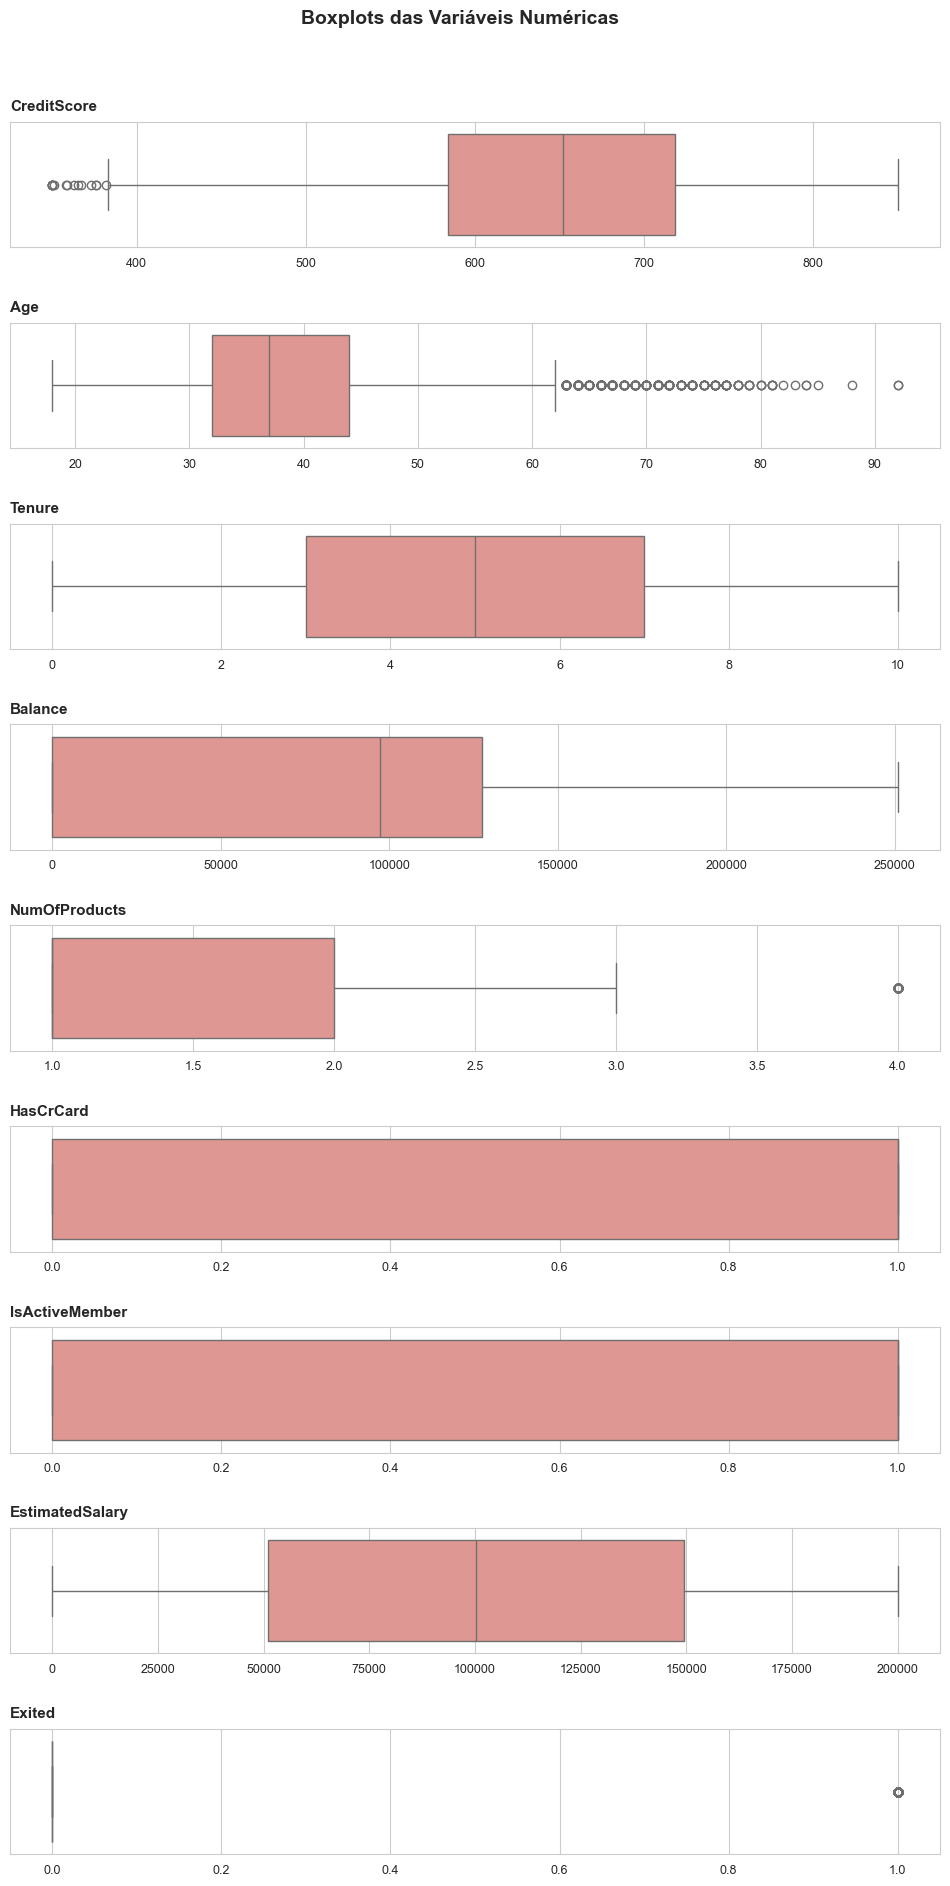

In [30]:
# Seleciona os nomes das colunas numéricas (float apenas)
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_remover = ['RowNumber', 'CustomerId']
colunas_numericas = [col for col in colunas_numericas if col not in colunas_remover] 

# Verifica se há colunas numéricas
if not colunas_numericas:
    print('Nenhuma variável numérica encontrada no DataFrame.')
else:
    # Número de boxplots a serem gerados
    n_plots = len(colunas_numericas)

    # Cria a figura com subplots verticais
    fig, axs = plt.subplots(n_plots, 1, figsize=(12, 2.5 * n_plots), 
                            gridspec_kw={'hspace': 0.6})

    # Garante que axs seja sempre uma lista (mesmo com 1 gráfico)
    if n_plots == 1:
        axs = [axs]

    # Loop pelas colunas para criar os boxplots
    for ax, col in zip(axs, colunas_numericas):
        sns.boxplot(x=df[col], ax=ax, color='#ea8c87', orient='h')
        ax.set_title(f'{col}', loc='left', fontsize=11, pad=8, fontweight='bold')
        ax.set(xlabel='', ylabel='')
        ax.tick_params(labelsize=9)
        ax.ticklabel_format(style='plain', axis='x')

    # Ajusta o layout e adiciona título geral
    fig.suptitle('Boxplots das Variáveis Numéricas', fontsize=14, fontweight='bold', y=0.93)
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # evita sobreposição com título
    plt.show()

In [31]:
# Seleciona as variáveis numéricas
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_remover = ['RowNumber', 'CustomerId']
colunas_numericas = [col for col in colunas_numericas if col not in colunas_remover] 

# Lista para armazenar as informações de outliers por coluna
resultados_outliers = []

for col in colunas_numericas:
    # Calcula quartis e intervalo interquartil (IIQ)
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IIQ = Q3 - Q1

    # Define limites inferior e superior para outliers
    limite_inferior = Q1 - 1.5 * IIQ
    limite_superior = Q3 + 1.5 * IIQ

    # Contagem de outliers abaixo e acima dos limites
    outliers_abaixo = (df[col] < limite_inferior).sum()
    outliers_acima = (df[col] > limite_superior).sum()
    
    # Calcula a quantidade total de outliers fora dos limites
    total_outliers = outliers_acima + outliers_abaixo
    
    # Calcula a porcentagem total de outliers fora dos limites
    total_outliers_perc = total_outliers / df.shape[0]
    
    # Armazena resultados em um dicionário
    resultados_outliers.append({
        'Variável': col,
        'IIQ': IIQ,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior,
        'Outliers Abaixo': outliers_abaixo,
        'Outliers Acima': outliers_acima,
        'Total Outliers': total_outliers,
        '% Outliers': round(total_outliers_perc * 100, 3)
    })
    
# Converte a lista de dicionários em um DataFrame
df_outliers = pd.DataFrame(resultados_outliers) 

# Ordena o DataFrame pela % de outliers em ordem decrescente
df_outliers.sort_values(by='% Outliers', ascending=False, inplace=True)  

# Exibe o DataFrame com os resultados
print('\nResumo dos Outliers por Variável (ordenado por maior %)')
display(df_outliers.reset_index(drop=True))


Resumo dos Outliers por Variável (ordenado por maior %)


,Variável,IIQ,Limite Inferior,Limite Superior,Outliers Abaixo,Outliers Acima,Total Outliers,% Outliers
0,Exited,0.0000,0.00000,0.00000,0,2037,2037,20.37
1,Age,12.0000,14.00000,62.00000,0,359,359,3.59
2,NumOfProducts,1.0000,-0.50000,3.50000,0,60,60,0.60
3,CreditScore,134.0000,383.00000,919.00000,15,0,15,0.15
4,Tenure,4.0000,-3.00000,13.00000,0,0,0,0.00
5,Balance,127644.2400,-191466.36000,319110.60000,0,0,0,0.00
6,HasCrCard,1.0000,-1.50000,2.50000,0,0,0,0.00
7,IsActiveMember,1.0000,-1.50000,2.50000,0,0,0,0.00
8,EstimatedSalary,98386.1375,-96577.09625,296967.45375,0,0,0,0.00


### 3.6. Distribuição das Variáveis Numéricas

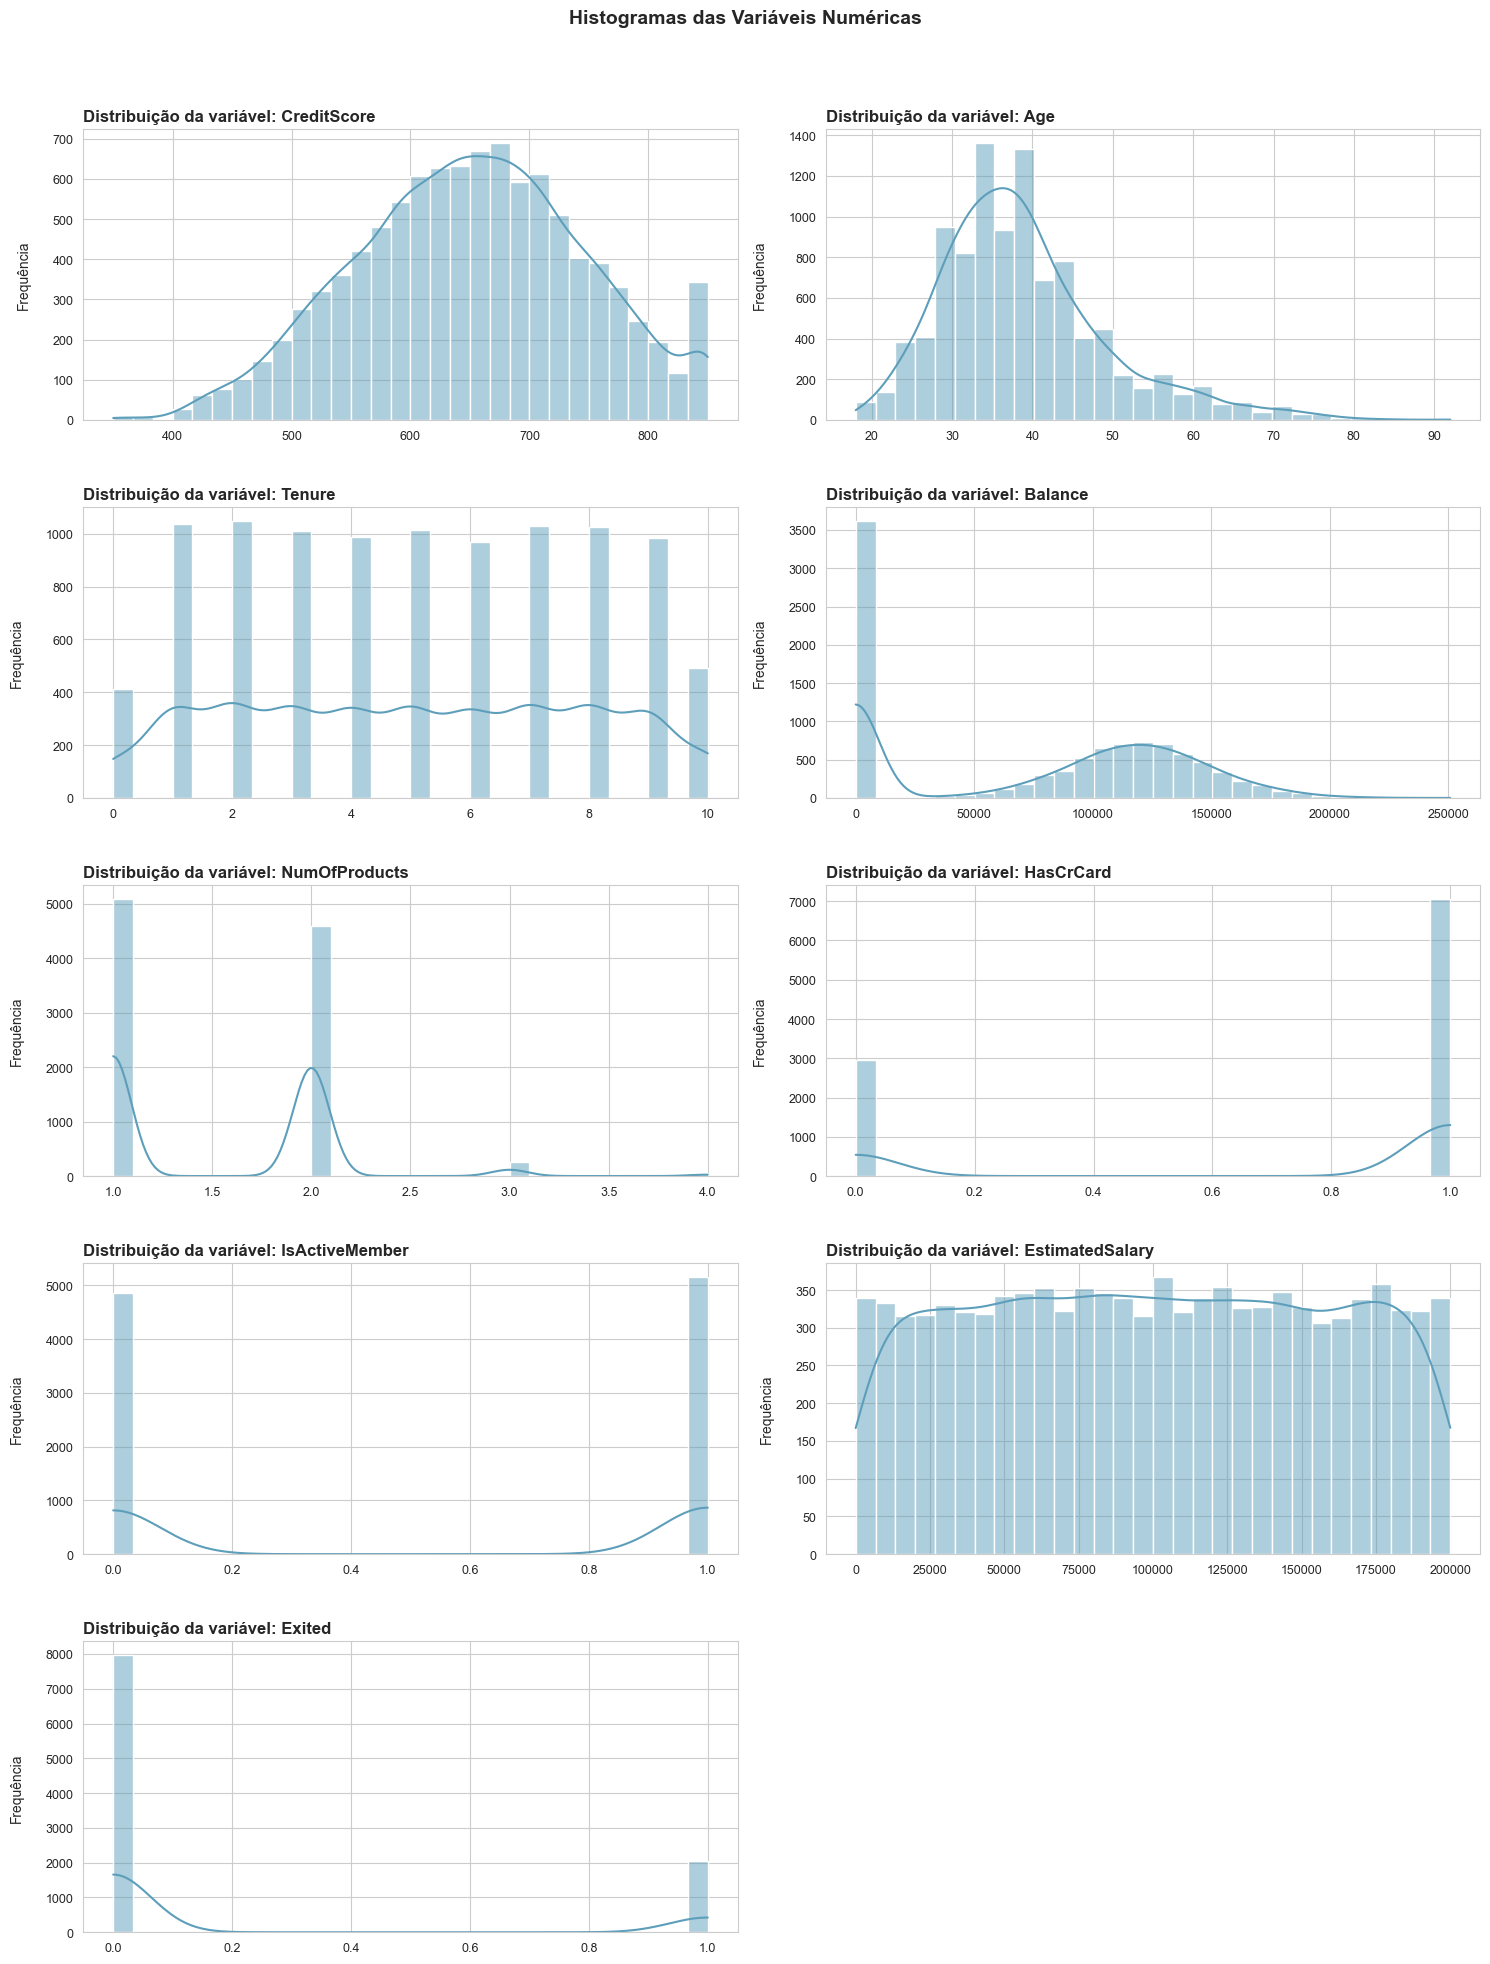

In [32]:
# Seleciona as variáveis numéricas
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_remover = ['RowNumber', 'CustomerId']
colunas_numericas = [col for col in colunas_numericas if col not in colunas_remover] 

# Calcula a quantidade de subplots necessários
qtde_subplots = len(colunas_numericas)

# Configuração para múltiplos gráficos: 2 colunas por linha
colunas_subplot = 2
qtde_linhas = -(-qtde_subplots // colunas_subplot)

# Criação da figura com subplots
fig, axs = plt.subplots(qtde_linhas, colunas_subplot, figsize=(15, 4 * qtde_linhas))

# Transformação do array de subplots para facilitar o loop
axs = axs.flatten()

# Remove subplots vazios, caso existam
for i in range(qtde_subplots, len(axs)):
    fig.delaxes(axs[i])

# Loop sobre as variáveis numéricas para criar os histogramas
for i, coluna in enumerate(colunas_numericas):
    sns.histplot(data=df, x=coluna, ax=axs[i], bins=30, kde=True, color='#5d9eba', edgecolor='#ffffff')

    # Configura o título e remove os rótulos dos eixos
    axs[i].set_title(f'Distribuição da variável: {coluna}', fontsize=12, loc='left', fontweight='bold')
    axs[i].set(xlabel='', ylabel='Frequência\n')

    # Ajusta o tamanho dos rótulos
    axs[i].tick_params(labelsize=9)

    # Exibe rótulos sem notação científica
    axs[i].ticklabel_format(style='plain', axis='x')

# Adiciona um título geral
fig.suptitle('Histogramas das Variáveis Numéricas', fontsize=14, fontweight='bold')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, top=0.92)  # Mais espaço entre os gráficos
plt.show()

### 3.7. Análise da Distribuição das Variáveis Numéricas

In [34]:
def test_normality(dataframe, col):
    '''
    Realiza testes estatísticos de normalidade (Shapiro-Wilk e D’Agostino-Pearson)
    para a variável numérica especificada.

    :param dataframe: DataFrame
        DataFrame contendo os dados a serem analisados.
    :param col: str
        Nome da coluna numérica a ser testada.
    :return: None
        Exibe os resultados dos testes e interpretação.
    '''

    # Remove valores ausentes da amostra
    amostra = dataframe[col].dropna()

    # Teste de Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(amostra)

    # Teste de D’Agostino-Pearson
    dagostino_stat, dagostino_p = stats.normaltest(amostra)

    # Exibição dos resultados
    print(f'\n📌 Teste de Normalidade — {coluna}\n')
    print(f'- Shapiro-Wilk:       Estatística = {shapiro_stat:.4f} | p-valor = {shapiro_p:.4f}')
    print(f'- D\'Agostino-Pearson: Estatística = {dagostino_stat:.4f} | p-valor = {dagostino_p:.4f}\n')

    # Interpretação
    if shapiro_p > 0.05 and dagostino_p > 0.05:
        print('✅ A variável apresenta distribuição normal (não rejeita H₀ nos dois testes).')
    else:
        print('⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).')

In [35]:
test_normality(df, 'CreditScore')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.9939 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 132.8284 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [36]:
test_normality(df, 'Age')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.9441 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 1507.7909 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [37]:
test_normality(df, 'Tenure')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.9486 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 6481.9183 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [38]:
test_normality(df, 'Balance')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.8456 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 62973.3895 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [39]:
test_normality(df, 'NumOfProducts')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.7061 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 832.9889 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [40]:
test_normality(df, 'HasCrCard')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.5721 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 8759.5374 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [41]:
test_normality(df, 'IsActiveMember')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.6363 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 34476.1454 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [42]:
test_normality(df, 'EstimatedSalary')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.9566 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 7397.1498 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


In [43]:
test_normality(df, 'Exited')


📌 Teste de Normalidade — Exited

- Shapiro-Wilk:       Estatística = 0.4939 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 2043.9545 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).
